In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [20]:
## read data
df = pd.read_csv("E:\SheRozgar Training\Datasets\House Price Prediction Dataset.csv")

# Display dataset
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [23]:
df.isnull().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

In [24]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


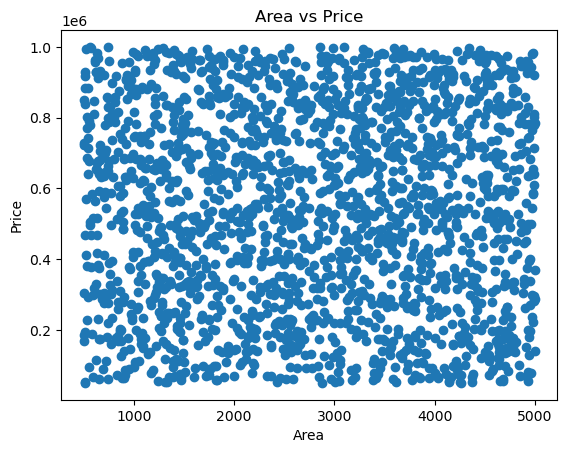

In [25]:
plt.scatter(df['Area'], df['Price'])
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Area vs Price")
plt.show()

In [26]:
from datetime import datetime

current_year = datetime.now().year
df['Age'] = current_year - df['YearBuilt']

# current_year = 2026  # or use dynamic method below

# df['Age'] = current_year - df['YearBuilt']

In [27]:
df.head(5)

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price,Age
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919,56
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998,68
2,3,3592,2,2,3,1938,Downtown,Good,No,266746,88
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020,124
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056,51


In [28]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price,Age
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000,64.554000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719,35.926695
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000,3.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000,33.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000,65.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000,96.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000,126.000000


In [11]:
X = df[['Area', 'Bedrooms', 'Age']]  # independent variables
y = df['Price']  # dependent variable

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [14]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 543539.2971233192
Coefficients: [  -0.13184628   31.85858852 -110.77943421]


In [15]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
comparison

,Actual,Predicted
1860,514764,529640.267743
353,694256,529215.327195
1333,66375,542047.767072
905,650243,540086.691962
1289,223285,539815.594319
...,...,...
965,386940,537128.733790
1284,632570,542090.054301
1739,494049,533562.184883
261,562193,530364.299864


In [16]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score (Accuracy):", r2)

MAE: 242644.90318882384
MSE: 77946329305.06284
RMSE: 279188.69838348194
R2 Score (Accuracy): -0.001895925529594944


In [17]:
new_house = [[2000, 3, 5]]  # Area, Bedrooms, Age
predicted_price = model.predict(new_house)

print("Predicted Price:", predicted_price[0])

Predicted Price: 542817.2831654684


C:\Users\A4TECH\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# X = [[1],[2],[3],[4],[5]]
# y = [40,50,65,85,95]

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

pred = model.predict(poly.transform([[6]]))
print(pred)